In [148]:
import numpy as np
from numpy.random import randn
import matplotlib.pyplot as plt
import numpy.random as random

import os
#exit the folder to the main folder
print("File location using os.getcwd():", os.getcwd())
os.chdir('../../')
print("File location using os.getcwd():", os.getcwd())

np.random.seed(56)

File location using os.getcwd(): /
File location using os.getcwd(): /


In [149]:
import pandas as pd
data_ex1 = pd.read_csv('https://www.nbi.dk/~koskinen/Teaching/AdvancedMethodsInAppliedStatistics2025/data/ParameterEstimation_Ex1.txt', sep=' ', header=None)
import scipy as sp

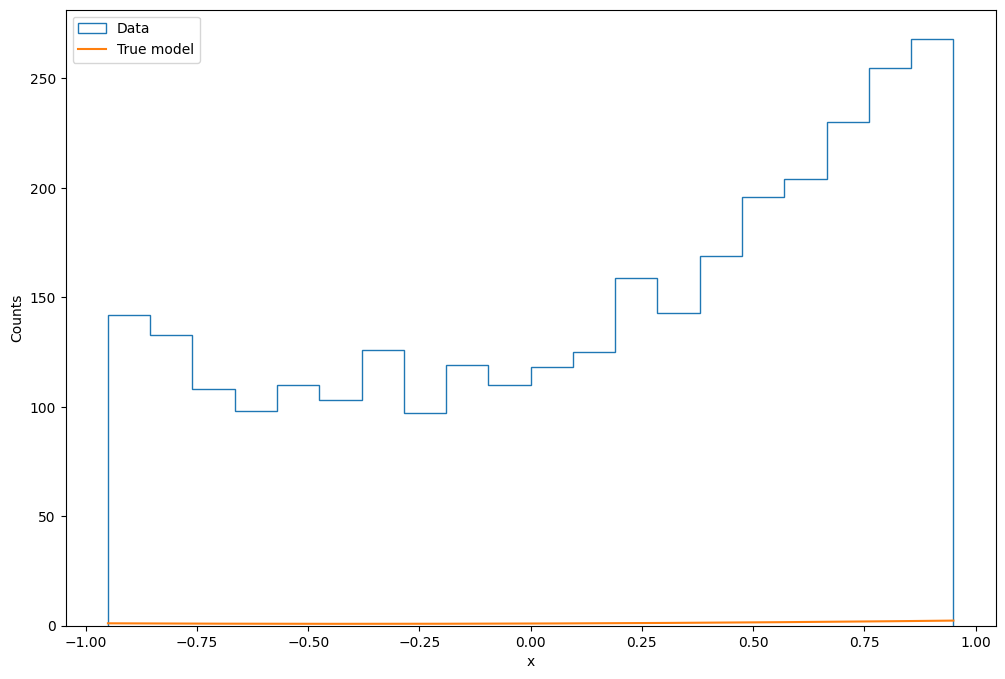

In [150]:
def function_1param(x,beta):
    return 1+0.65*x+beta*x**2

x_range = (-0.95,0.95)
xes = np.linspace(x_range[0],x_range[1],10000)
bins_ex1 = np.linspace(x_range[0],x_range[1],21)
normalization_factor = sp.integrate.quad(lambda x: function_1param(x,0.8),x_range[0],x_range[1])[0]

init_fig, init_ax = plt.subplots(1,1,figsize = (12,8))
counts_data, bins_data, plot_data = init_ax.hist(data_ex1[0], bins=bins_ex1, histtype='step', label='Data')

bin_centers = 0.5*(bins_data[1:]+bins_data[:-1])

init_ax.plot(xes, function_1param(xes,0.8), label='True model')
init_ax.set_xlabel('x')
init_ax.set_ylabel('Counts')
init_ax.legend(loc= 'upper left')

In [151]:
import iminuit as im
from iminuit import Minuit
from scipy.integrate import quad

In [152]:
# Normalize the function over the range -0.95 to 0.95
def normalize_func( beta):
    integral, _ = quad(function_1param, -0.95, 0.95, args=(beta))
    return integral

# Negative Log-Likelihood (NLL) Function
def neg_log_likelihood(beta):
    norm_factor = normalize_func(beta)
    pdf_vals = function_1param(np.array(data_ex1),beta) / norm_factor
    
    log_likelihood = np.sum(np.log(pdf_vals))
    
    return -2*log_likelihood  # Return negative log-likelihood for minimization

minuit = Minuit(neg_log_likelihood, beta=0.8) 
minuit.errordef = Minuit.LIKELIHOOD
minuit.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3558                       │              Nfcn = 19               │
│ EDM = 2.07e-08 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ beta │   0.88    │   0.07    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────┬─────────┐
│      │    beta │
├──────┼─────────┤
│ beta │ 0.00453 │
└──────┴─────────┘

In [153]:
beta_space = np.linspace(0.5, 1.5, 1000)
nll_vals = np.array([neg_log_likelihood(beta) for beta in beta_space])

# find the places where the nll is 0.5 larger than the minimum on both sides of the minimum
min_nll = minuit.values['beta']

sigma_plus_ind = np.where(nll_vals < minuit.fval + 0.5)[0][-1]
sigma_minus_ind = np.where(nll_vals < minuit.fval + 0.5)[0][0]

sigma_plus = beta_space[sigma_plus_ind]
sigma_minus = beta_space[sigma_minus_ind]

print(r'$\beta = {:.2f} {{+{:.2f}}}_{{-{:.2f}}}$'.format(min_nll, sigma_plus-min_nll, min_nll-sigma_minus))

$\beta = 0.88 {+0.07}_{-0.07}$


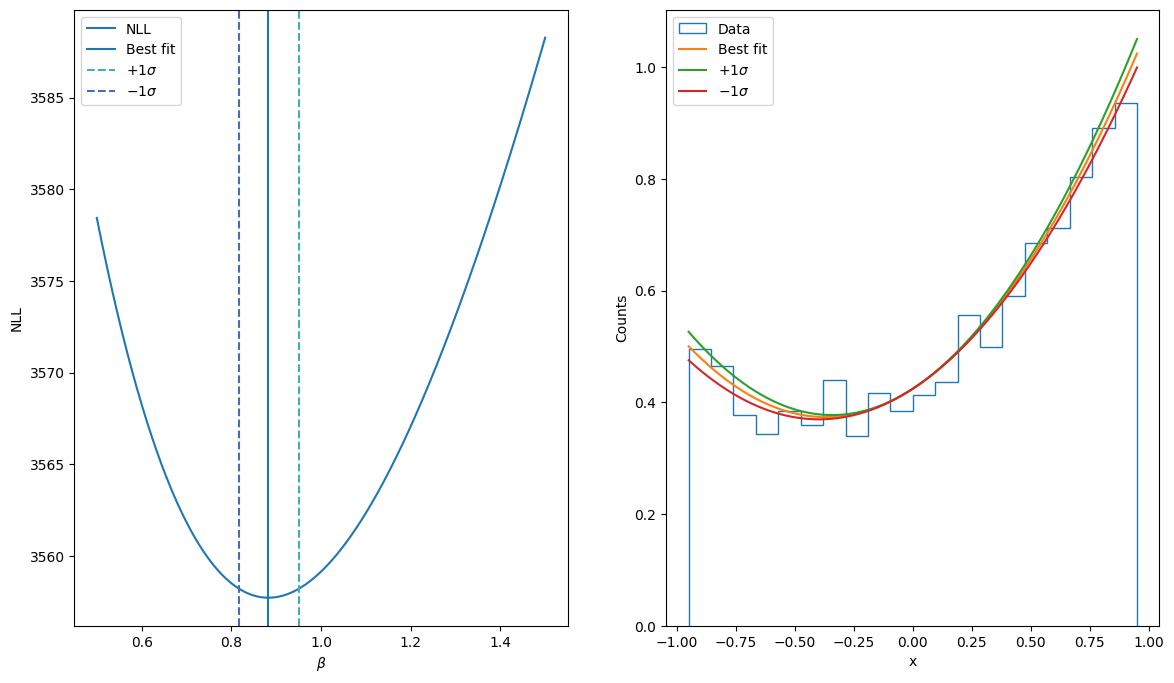

In [154]:
colors = ['#41AFAA', '#466EB4', '#00A0E1', '#E6A532', '#D7642C', '#AF4B91']

fig_1param_fit, ax_1param_fit = plt.subplots(1,2,figsize = (14,8))
ax_1param_fit[0].plot(beta_space, nll_vals, label='NLL')
ax_1param_fit[0].axvline(min_nll, label='Best fit')
ax_1param_fit[0].axvline(sigma_plus, linestyle='--', label=r'$+1\sigma$',color=colors[0])
ax_1param_fit[0].axvline(sigma_minus, linestyle='--', label=r'$-1\sigma$',color=colors[1])
ax_1param_fit[0].set_xlabel(r'$\beta$')
ax_1param_fit[0].set_ylabel('NLL')
ax_1param_fit[0].legend()

counts_data, bins_data, plot_data = ax_1param_fit[1].hist(data_ex1[0], bins=bins_ex1, histtype='step', label='Data',density=True)
bin_centers = 0.5*(bins_data[1:]+bins_data[:-1])
ax_1param_fit[1].plot(xes, function_1param(xes,min_nll)/normalization_factor, label='Best fit')
ax_1param_fit[1].plot(xes, function_1param(xes,sigma_plus)/normalization_factor, label=r'$+1\sigma$')
ax_1param_fit[1].plot(xes, function_1param(xes,sigma_minus)/normalization_factor, label=r'$-1\sigma$')
ax_1param_fit[1].set_xlabel('x')
ax_1param_fit[1].set_ylabel('Counts')
ax_1param_fit[1].legend(loc= 'upper left')

## Exercise 2 a + d

Number of function evaluations: 1071


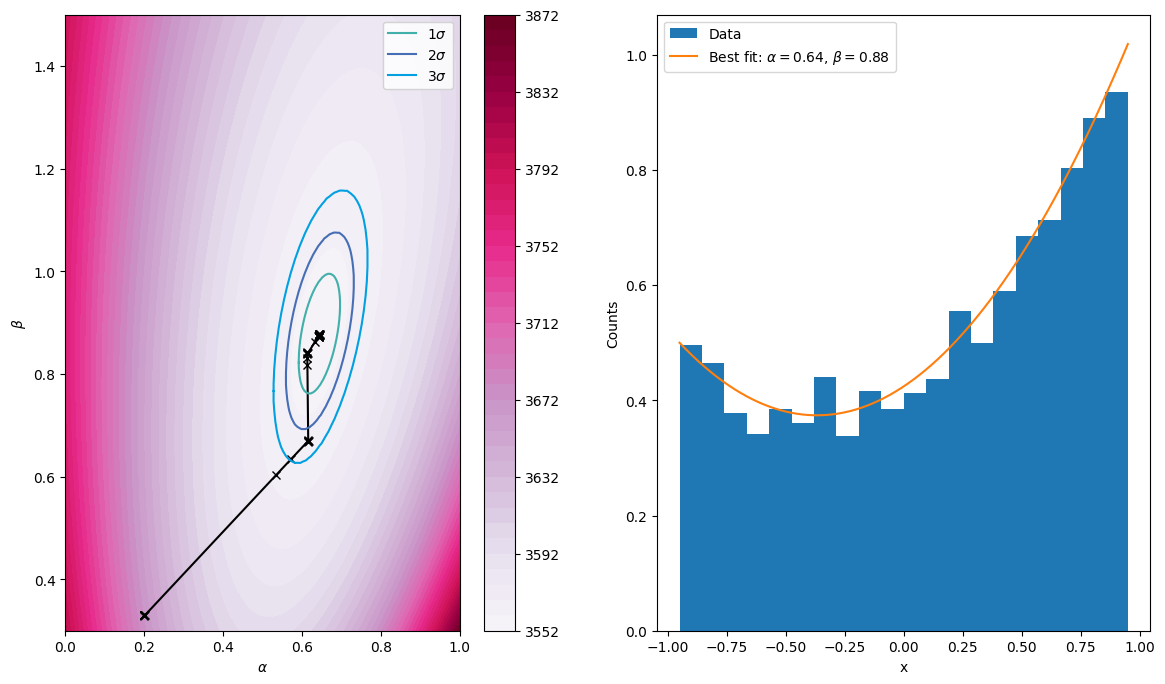

In [155]:
function_2param = lambda x, alpha, beta: 1+alpha*x+beta*x**2

def normalized_func_2param(alpha, beta, data = np.array(data_ex1)):
    integral, _ = quad(function_2param, -0.95, 0.95, args = (alpha, beta))
    return function_2param(data, alpha, beta) / integral

step_history = []
def neg_log_likelihood_2param(alpha, beta):
    pdf_vals = normalized_func_2param(alpha, beta)
    log_likelihood = np.sum(np.log(pdf_vals))
    step_history.append((alpha, beta))
    return -2*log_likelihood  # Return negative log-likelihood for minimization

minuit_2param = Minuit(neg_log_likelihood_2param, alpha=0.2, beta=0.33)
minuit_2param.errordef = Minuit.LIKELIHOOD
minuit_2param.migrad()
alpha_steps, beta_steps = zip(*step_history)

alpha_space = np.linspace(0., 1, 100)
beta_space = np.linspace(0.3, 1.5, 100)

# Compute the ln likelihood for the 2D space
nll_vals_2param = np.array([[neg_log_likelihood_2param(alpha, beta) for alpha in alpha_space] for beta in beta_space])

# Plotting the uncertainty contours related to 1, 2 and 3 sigma using mn.contourf
count_1_sigma = minuit_2param.mncontour('alpha', 'beta', size = 100, cl = 1).T 
count_2_sigma = minuit_2param.mncontour('alpha', 'beta', size = 100, cl = 2).T
count_3_sigma = minuit_2param.mncontour('alpha', 'beta', size = 100, cl = 3).T

fig_2param_fit, ax_2param_fit = plt.subplots(1,2,figsize = (14,8))
contor = ax_2param_fit[0].contourf(alpha_space, beta_space, nll_vals_2param, levels=50, cmap='PuRd')
fig_2param_fit.colorbar(contor, ax = ax_2param_fit[0])
ax_2param_fit[0].plot(alpha_steps, beta_steps, 'x-', color='black', alpha=1)
ax_2param_fit[0].set_xlabel(r'$\alpha$')
ax_2param_fit[0].set_ylabel(r'$\beta$')

# Plotting the contours
ax_2param_fit[0].plot(count_1_sigma[0], count_1_sigma[1], label='1$\sigma$', color=colors[0])
ax_2param_fit[0].plot(count_2_sigma[0], count_2_sigma[1], label='2$\sigma$', color=colors[1])
ax_2param_fit[0].plot(count_3_sigma[0], count_3_sigma[1], label='3$\sigma$', color=colors[2])
ax_2param_fit[0].legend()

counts_data, bins_data, plot_data = ax_2param_fit[1].hist(data_ex1[0], bins=bins_ex1, label='Data',density=True)
bin_centers = 0.5*(bins_data[1:]+bins_data[:-1])
ax_2param_fit[1].plot(xes, function_2param(xes,minuit_2param.values['alpha'],minuit_2param.values['beta'])/normalization_factor, label='Best fit: $\\alpha = {:.2f}$, $\\beta = {:.2f}$'.format(minuit_2param.values['alpha'],minuit_2param.values['beta'])) 
ax_2param_fit[1].set_xlabel('x')
ax_2param_fit[1].set_ylabel('Counts')
ax_2param_fit[1].legend(loc= 'upper left')

print('Number of function evaluations:', minuit_2param.nfcn)

## Exercise 2 b

In [156]:
import functools

N_pseudo_trials = 500
N_data_points = len(data_ex1)
x_range = (-0.95, 0.95)

function_2param = lambda x, alpha, beta: 1 + alpha * x + beta * x**2

def normalized_func_2param(data, alpha, beta):
    integral, _ = quad(function_2param, -0.95, 0.95, args = (alpha, beta))
    return function_2param(data, alpha, beta) / integral

def llh_booststrap(alpha, beta, data):
    pdf_vals = normalized_func_2param(data, alpha, beta)
    log_likelihood = np.sum(np.log(pdf_vals))
    return -2 * log_likelihood

def parametric_bootstrap(data, N_pseudo_trials, N_data_points, x_range):
    pseudo_data_alpha, pseudo_data_beta = np.zeros(N_pseudo_trials), np.zeros(N_pseudo_trials)

    for i in range(N_pseudo_trials):
        # Generate data from the model
        x_bootstrap = np.random.uniform(x_range[0], x_range[1], N_data_points)
        y_bootstrap = np.random.uniform(0, 1, N_data_points)

        # Using accept-reject method
        bootstrapped_data = x_bootstrap[y_bootstrap < normalized_func_2param(
            x_bootstrap, minuit_2param.values['alpha'], minuit_2param.values['beta']
        )]

        # Define a lambda function that fixes the data and only optimizes alpha, beta
        llh_fixed_data = lambda alpha, beta: llh_booststrap(alpha, beta, bootstrapped_data)

        # Minuit only takes two parameters now
        minuit_pseudo = Minuit(llh_fixed_data, alpha = 0.2, beta = 0.33)
        minuit_pseudo.errordef = Minuit.LIKELIHOOD
        minuit_pseudo.migrad()

        pseudo_data_alpha[i] = minuit_pseudo.values['alpha']
        pseudo_data_beta[i] = minuit_pseudo.values['beta']

    return pseudo_data_alpha, pseudo_data_beta

In [157]:
pseudo_alpha, pseudo_beta = parametric_bootstrap(data_ex1, N_pseudo_trials, N_data_points, x_range)

In [158]:
# Compute 68.27% confidence intervals (16th and 84th percentiles)
alpha_lower, alpha_upper = np.percentile(pseudo_alpha, [16, 84])
beta_lower, beta_upper = np.percentile(pseudo_beta, [16, 84])

# Print results
print(f"68.27% Confidence Interval for alpha: [{alpha_lower:.4f}, {alpha_upper:.4f}]")
print(f"68.27% Confidence Interval for beta: [{beta_lower:.4f}, {beta_upper:.4f}]")

68.27% Confidence Interval for alpha: [0.5726, 0.7019]
68.27% Confidence Interval for beta: [0.7151, 1.0121]


Text(0, 0.5, '$\\beta$')

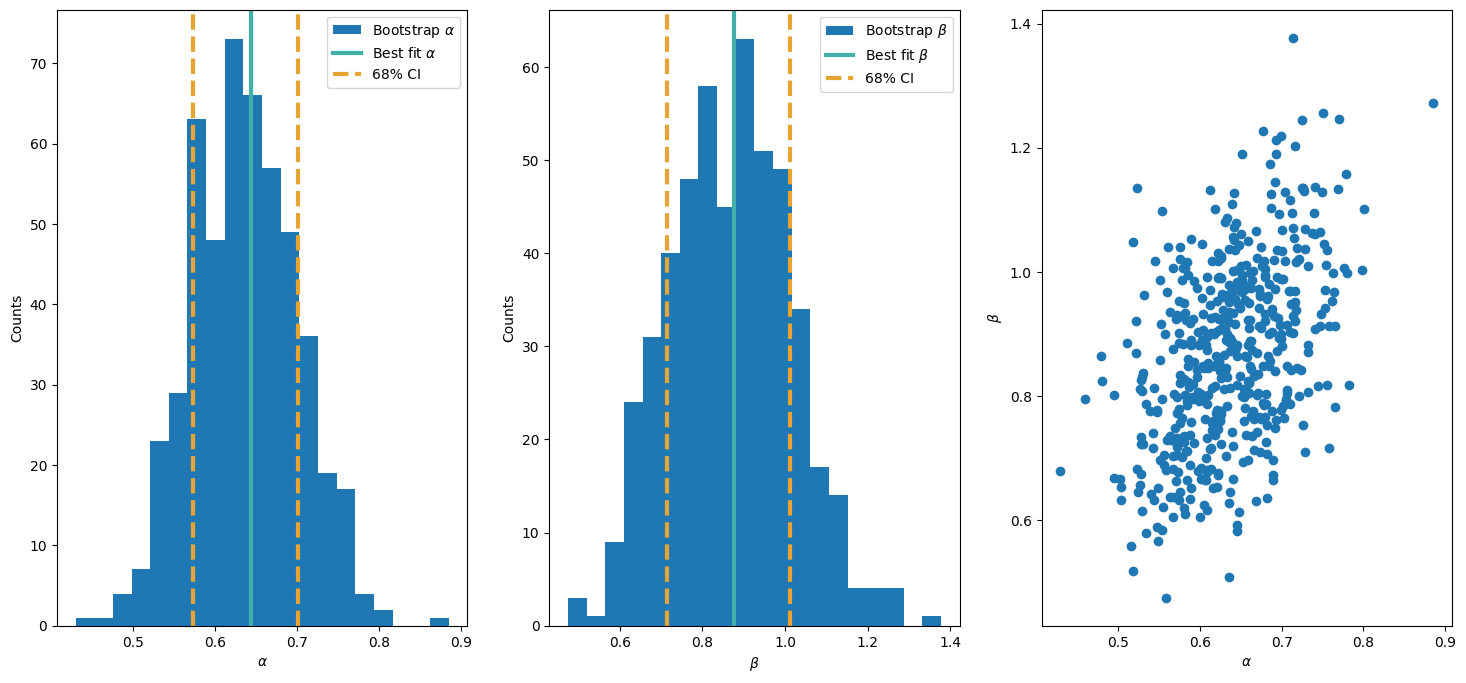

In [159]:
fig_bootstrap, ax_bootstrap = plt.subplots(1,3,figsize = (18,8))
ax_bootstrap[0].hist(pseudo_alpha, bins=20, label='Bootstrap $\\alpha$')
ax_bootstrap[0].axvline(minuit_2param.values['alpha'], label='Best fit $\\alpha$',color=colors[0],lw = 3)
# plot the 68% confidence interval
ax_bootstrap[0].axvline(alpha_lower, linestyle='--', label='68% CI',color=colors[3],lw = 3)
ax_bootstrap[0].axvline(alpha_upper, linestyle='--',color=colors[3],lw = 3)

ax_bootstrap[0].set_xlabel(r'$\alpha$')
ax_bootstrap[0].set_ylabel('Counts')
ax_bootstrap[0].legend()

ax_bootstrap[1].hist(pseudo_beta, bins=20, label='Bootstrap $\\beta$')
ax_bootstrap[1].axvline(minuit_2param.values['beta'], label='Best fit $\\beta$',color=colors[0],lw = 3)
# plot the 68% confidence interval
ax_bootstrap[1].axvline(beta_lower, linestyle='--', label='68% CI',color=colors[3],lw = 3)
ax_bootstrap[1].axvline(beta_upper, linestyle='--',color=colors[3],lw = 3)
ax_bootstrap[1].set_xlabel(r'$\beta$')
ax_bootstrap[1].set_ylabel('Counts')
ax_bootstrap[1].legend()

ax_bootstrap[2].scatter(pseudo_alpha, pseudo_beta, label='Bootstrap $\\alpha$ vs $\\beta$')
ax_bootstrap[2].set_xlabel(r'$\alpha$')
ax_bootstrap[2].set_ylabel(r'$\beta$')

# Exercise 3

In [160]:
data_ex3 = pd.read_csv('https://www.nbi.dk/~koskinen/Teaching/AdvancedMethodsInAppliedStatistics2025/data/MLE_Variance_data.txt', sep=' ', header = None)
print(data_ex3)

           0       1   2
0     0.4802  0.7249 NaN
1    -0.0180  0.8279 NaN
2    -0.6982 -0.8013 NaN
3     0.2868  0.1658 NaN
4     0.5779  0.9663 NaN
...      ...     ...  ..
1995  0.4719  0.3761 NaN
1996  0.0818  0.9412 NaN
1997  0.8465  0.6446 NaN
1998  0.8911  0.3494 NaN
1999  0.6662  0.3807 NaN

[2000 rows x 3 columns]


In [161]:
x_1 = np.array(data_ex3[0])
x_2 = np.array(data_ex3[1])

print(x_1)
print(x_2)

x_range = (-1, 1)
bins_ex3 = np.linspace(x_range[0], x_range[1], 21)
xes = np.linspace(x_range[0], x_range[1], 10000)

[ 0.4802 -0.018  -0.6982 ...  0.8465  0.8911  0.6662]
[ 0.7249  0.8279 -0.8013 ...  0.6446  0.3494  0.3807]


Number of function evaluations: 928


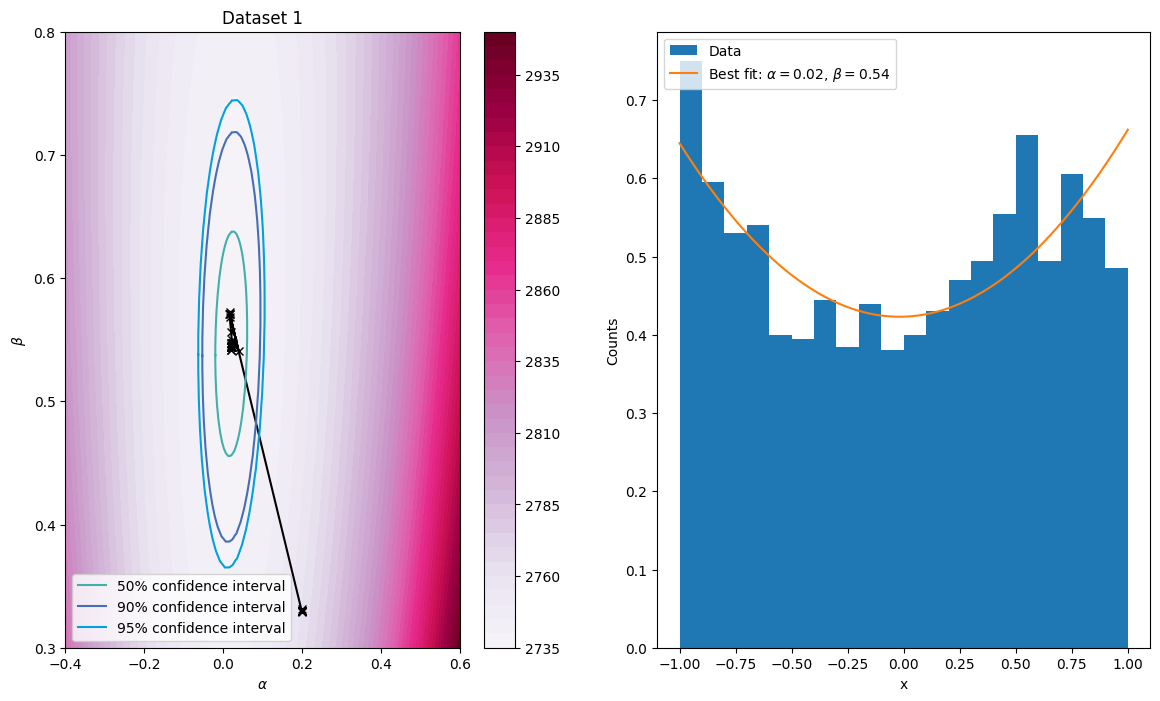

In [162]:
def normalized_func_2param(alpha, beta, data = x_1):
    integral, _ = quad(function_2param, -1, 1, args = (alpha, beta))
    return function_2param(data, alpha, beta) / integral

step_history = []
def neg_log_likelihood_2param(alpha, beta):
    pdf_vals = normalized_func_2param(alpha, beta)
    log_likelihood = np.sum(np.log(pdf_vals))
    step_history.append((alpha, beta))
    return -2*log_likelihood  # Return negative log-likelihood for minimization

minuit_2param = Minuit(neg_log_likelihood_2param, alpha=0.2, beta=0.33)
minuit_2param.errordef = Minuit.LIKELIHOOD
minuit_2param.migrad()
alpha_steps, beta_steps = zip(*step_history)

alpha_space = np.linspace(-0.4, 0.6, 100)
beta_space = np.linspace(0.3, 0.8, 100)

normalization_factor = sp.integrate.quad(lambda x: function_2param(x, minuit_2param.values['alpha'], minuit_2param.values['beta']), x_range[0], x_range[1])[0]

# Compute the ln likelihood for the 2D space
nll_vals_2param = np.array([[neg_log_likelihood_2param(alpha, beta) for alpha in alpha_space] for beta in beta_space])

# Plotting the uncertainty contours related to 1, 2 and 3 sigma using mn.contourf
count_1_sigma = minuit_2param.mncontour('alpha', 'beta', size = 100, cl = 0.5).T 
count_2_sigma = minuit_2param.mncontour('alpha', 'beta', size = 100, cl = 0.9).T
count_3_sigma = minuit_2param.mncontour('alpha', 'beta', size = 100, cl = 0.95).T

fig_2param_fit, ax_2param_fit = plt.subplots(1,2,figsize = (14,8))
contor = ax_2param_fit[0].contourf(alpha_space, beta_space, nll_vals_2param, levels=50, cmap='PuRd')
fig_2param_fit.colorbar(contor, ax = ax_2param_fit[0])
ax_2param_fit[0].plot(alpha_steps, beta_steps, 'x-', color='black', alpha=1)
ax_2param_fit[0].set_xlabel(r'$\alpha$')
ax_2param_fit[0].set_ylabel(r'$\beta$')
ax_2param_fit[0].set_title('Dataset 1')

# Plotting the contours
ax_2param_fit[0].plot(count_1_sigma[0], count_1_sigma[1], label='50% confidence interval', color=colors[0])
ax_2param_fit[0].plot(count_2_sigma[0], count_2_sigma[1], label='90% confidence interval', color=colors[1])
ax_2param_fit[0].plot(count_3_sigma[0], count_3_sigma[1], label='95% confidence interval', color=colors[2])
ax_2param_fit[0].legend()

counts_data, bins_data, plot_data = ax_2param_fit[1].hist(x_1, bins=bins_ex3, label='Data',density=True)
ax_2param_fit[1].plot(xes, function_2param(xes, minuit_2param.values['alpha'],minuit_2param.values['beta'])/normalization_factor, label='Best fit: $\\alpha = {:.2f}$, $\\beta = {:.2f}$'.format(minuit_2param.values['alpha'],minuit_2param.values['beta'])) 
ax_2param_fit[1].set_xlabel('x')
ax_2param_fit[1].set_ylabel('Counts')
ax_2param_fit[1].legend(loc= 'upper left')

print('Number of function evaluations:', minuit_2param.nfcn)

Chi-squared value: 81477.42339749685
Degrees of freedom: 98
P-value: 0.0


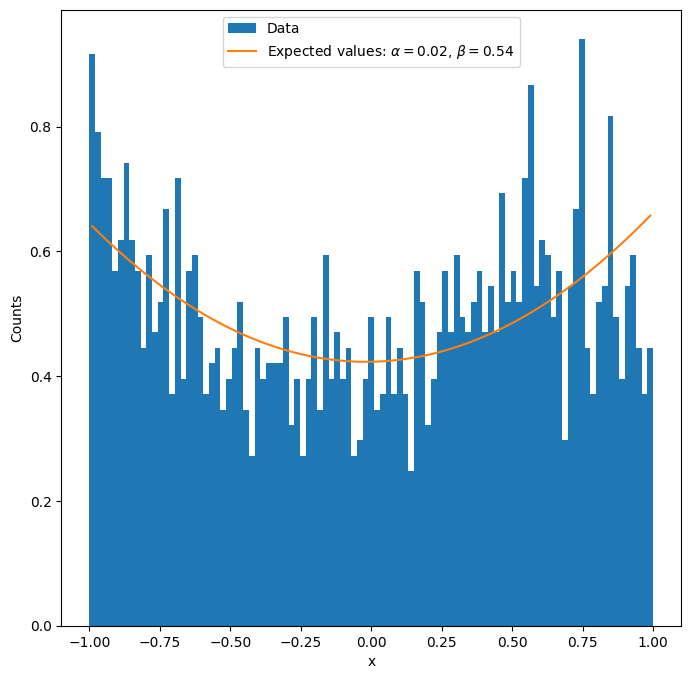

In [163]:
# Using chi-squared test to determine the goodness of fit (p-value)

# Histogramming the data 
bins_ex3_1 = np.linspace(x_range[0], x_range[1], 100)
counts, bin_edges = np.histogram(x_1, bins = bins_ex3_1, density = False)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

# Computing the expected values from the model
expected_values = function_2param(bin_centers, minuit_2param.values['alpha'], minuit_2param.values['beta']) / normalization_factor 

# Computing the chi-squared value
chi_squared = np.sum((counts - expected_values)**2 / expected_values)

# Computing the degrees of freedom
dof = len(bins_ex3_1) - 2

# Computing the p-value
p_value = 1 - sp.stats.chi2.cdf(chi_squared, dof)

print(f"Chi-squared value: {chi_squared}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value}")

# Plotting
fig_chi_squared, ax_chi_squared = plt.subplots(1, 1, figsize = (8,8))

ax_chi_squared.hist(x_1, bins = bins_ex3_1, label = 'Data', density = True)
ax_chi_squared.plot(bin_centers, expected_values, label = r'Expected values: $\alpha = {:.2f}$, $\beta = {:.2f}$'.format(minuit_2param.values['alpha'], minuit_2param.values['beta']))
ax_chi_squared.set_xlabel('x')
ax_chi_squared.set_ylabel('Counts')
ax_chi_squared.legend()

/var/folders/ws/45wzf3p157x_56fnsrq6bc4w0000gn/T/ipykernel_3188/1671164332.py:8: RuntimeWarning: invalid value encountered in log
  log_likelihood = np.sum(np.log(pdf_vals))


Number of function evaluations: 1102


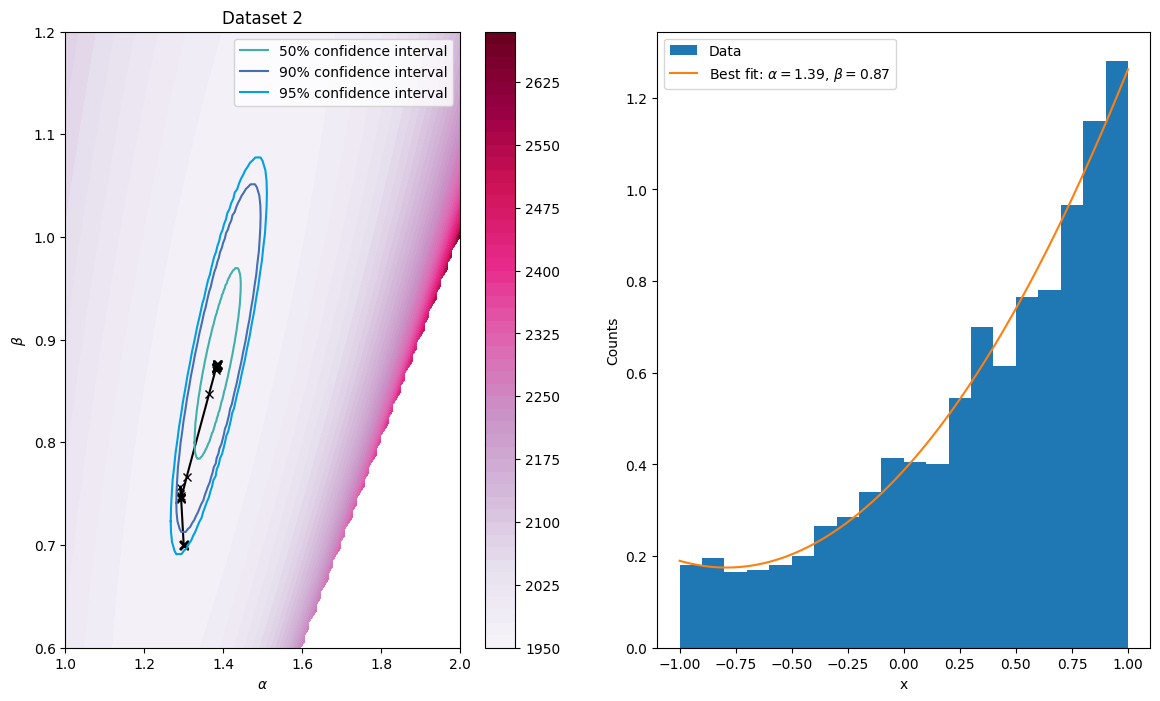

In [164]:
def normalized_func_2param(alpha, beta, data = x_2):
    integral, _ = quad(function_2param, -1, 1, args = (alpha, beta))
    return function_2param(data, alpha, beta) / integral

step_history = []
def neg_log_likelihood_2param(alpha, beta):
    pdf_vals = normalized_func_2param(alpha, beta)
    log_likelihood = np.sum(np.log(pdf_vals))
    step_history.append((alpha, beta))
    return -2*log_likelihood  # Return negative log-likelihood for minimization

minuit_2param = Minuit(neg_log_likelihood_2param, alpha=1.3, beta=0.7)
minuit_2param.errordef = Minuit.LIKELIHOOD
minuit_2param.migrad()
alpha_steps, beta_steps = zip(*step_history)

alpha_space = np.linspace(1, 2, 100)
beta_space = np.linspace(0.6, 1.2, 100)

normalization_factor = sp.integrate.quad(lambda x: function_2param(x, minuit_2param.values['alpha'], minuit_2param.values['beta']), x_range[0], x_range[1])[0]

# Compute the ln likelihood for the 2D space
nll_vals_2param = np.array([[neg_log_likelihood_2param(alpha, beta) for alpha in alpha_space] for beta in beta_space])

# Plotting the uncertainty contours related to 1, 2 and 3 sigma using mn.contourf
count_50 = minuit_2param.mncontour('alpha', 'beta', size=100, cl = 0.5).T
count_90 = minuit_2param.mncontour('alpha', 'beta', size=100, cl = 0.9).T
count_95 = minuit_2param.mncontour('alpha', 'beta', size=100, cl = 0.95).T

fig_2param_fit, ax_2param_fit = plt.subplots(1, 2, figsize = (14,8))
contor = ax_2param_fit[0].contourf(alpha_space, beta_space, nll_vals_2param, levels=50, cmap='PuRd')
fig_2param_fit.colorbar(contor, ax = ax_2param_fit[0])
ax_2param_fit[0].plot(alpha_steps, beta_steps, 'x-', color='black', alpha=1)
ax_2param_fit[0].set_xlabel(r'$\alpha$')
ax_2param_fit[0].set_ylabel(r'$\beta$')
ax_2param_fit[0].set_title('Dataset 2')

# Plotting the contours
ax_2param_fit[0].plot(count_50[0], count_50[1], label='50% confidence interval', color=colors[0])
ax_2param_fit[0].plot(count_90[0], count_90[1], label='90% confidence interval', color=colors[1])
ax_2param_fit[0].plot(count_95[0], count_95[1], label='95% confidence interval', color=colors[2])
ax_2param_fit[0].legend()

counts_data, bins_data, plot_data = ax_2param_fit[1].hist(x_2, bins=bins_ex3, label='Data',density=True)
bin_centers = 0.5*(bins_data[1:]+bins_data[:-1])
ax_2param_fit[1].plot(xes, function_2param(xes, minuit_2param.values['alpha'],minuit_2param.values['beta'])/normalization_factor, label='Best fit: $\\alpha = {:.2f}$, $\\beta = {:.2f}$'.format(minuit_2param.values['alpha'],minuit_2param.values['beta'])) 
ax_2param_fit[1].set_xlabel('x')
ax_2param_fit[1].set_ylabel('Counts')
ax_2param_fit[1].legend(loc= 'best')

print('Number of function evaluations:', minuit_2param.nfcn)

Chi-squared value: 80071.54022161354
Degrees of freedom: 98
P-value: 0.0


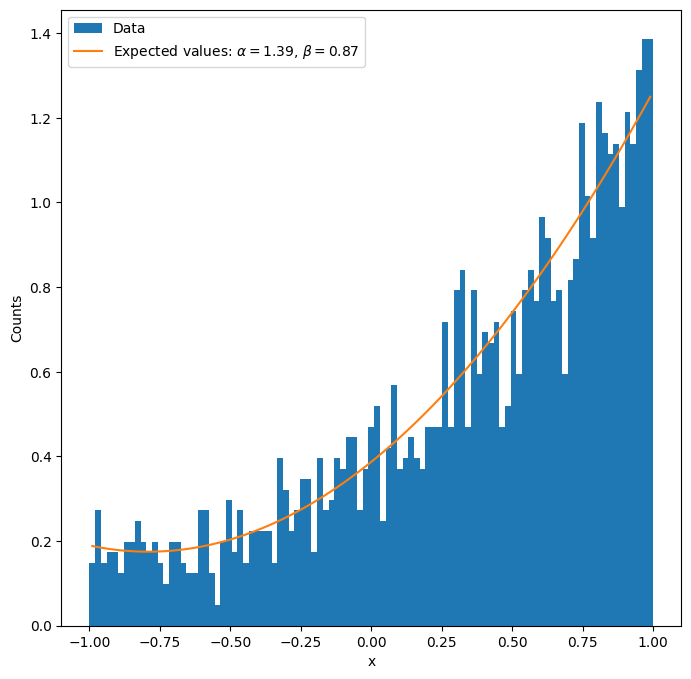

In [165]:
# Using chi-squared test to determine the goodness of fit (p-value)

# Histogramming the data 
bins_ex3_1 = np.linspace(x_range[0], x_range[1], 100)
counts, bin_edges = np.histogram(x_2, bins = bins_ex3_1, density = False)
bin_centers = 0.5*(bin_edges[1:]+bin_edges[:-1])

# Computing the expected values from the model
expected_values = function_2param(bin_centers, minuit_2param.values['alpha'], minuit_2param.values['beta']) / normalization_factor

# Computing the chi-squared value
chi_squared = np.sum((counts - expected_values)**2 / expected_values)

# Computing the degrees of freedom
dof = len(bins_ex3_1) - 2

# Computing the p-value
p_value = 1 - sp.stats.chi2.cdf(chi_squared, dof)

print(f"Chi-squared value: {chi_squared}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value}")

# Plotting
fig_chi_squared, ax_chi_squared = plt.subplots(1, 1, figsize = (8,8))

ax_chi_squared.hist(x_2, bins = bins_ex3_1, label = 'Data', density = True)
ax_chi_squared.plot(bin_centers, expected_values, label = r'Expected values: $\alpha = {:.2f}$, $\beta = {:.2f}$'.format(minuit_2param.values['alpha'], minuit_2param.values['beta']))
ax_chi_squared.set_xlabel('x')
ax_chi_squared.set_ylabel('Counts')
ax_chi_squared.legend()